In [1]:
%load_ext autoreload
%autoreload 2

In [156]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines
from models.gmp import GMP, GMPTensor, GMPCP, BaseModel
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

Load data from files

In [140]:
# dataset_path = "datasets/Custom_dataset"
# dataset_path = "datasets/DPA_200MHz"
# dataset_path = "datasets/Huawei_dataset"
dataset_path = "datasets/signal_samples_newPA_vo_filter_no_atten_-17_dBm"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.get_gained_signals()

print(f"gain: {container.gain}")

frame_length = 64
batch_size = 128
batch_size_eval = 2048

gain: 69.86884307861328


Algorithm 3 ALS algorithm for the identification of GMP-CP model

In [ ]:
R=3
M1=11
M2=10
P=8
N=2048

gamma = 1e-3
L = 30
# torch.manual_seed(42)

model = GMPCP(R=R, M1=M1, M2=M2, P=P, model_name='pa')

N_delay = len(container.train_input) - max(M1, M2) + 1

y_vec, H, M = data_loader.prepare_data_for_als(x=container.train_input,
                                    y=container.train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )

In [ ]:


model = learning.als_identification_of_gmpcp(model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)

# model.save_weights()

In [143]:
x = utils.iq_to_complex(container.val_input_orig)

with torch.no_grad():
    y_pred = model(x)


delay = max(model.M1, model.M2) - 1

y_true = utils.iq_to_complex(container.val_output[delay:])

gmpcp_nmse = metrics.compute_nmse(y_pred, y_true)
print(F"NMSE: {gmpcp_nmse:.2f} dB")

gmpcp_acepr = metrics.compute_acepr(
    measured=y_pred,
    predicted=y_true,
    fs=container.input_signal_fs,
    main_bandwidth=container.bw_main_ch,
    adjacent_bandwidth=container.bw_main_ch,
    channel_offset=container.bw_main_ch,
    nperseg=container.nperseg
)

print(f"ACEPR: {gmpcp_acepr:.2f} dB")

NMSE: -20.94 dB
ACEPR: -40.68 dB


In [145]:
container.to_complex()
# container.to_iq()


with torch.autograd.profiler.profile(use_cuda=False) as prof:
    with torch.no_grad():
        output = model.forward(container.val_input)

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                    Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
            aten::einsum         3.98%      75.900us        44.53%     849.400us     424.700us             2  
               aten::bmm        31.04%     592.000us        33.75%     643.800us     321.900us             2  
             aten::stack         0.94%      18.000us        13.92%     265.500us     265.500us             1  
               aten::cat        11.70%     223.100us        12.16%     232.000us     232.000us             1  
             aten::index         7.73%     147.500us         8.13%     155.000us      77.500us             2  
               aten::mul         6.02%     114.900us         7.91%     150.800us      16.756us             9  
 

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


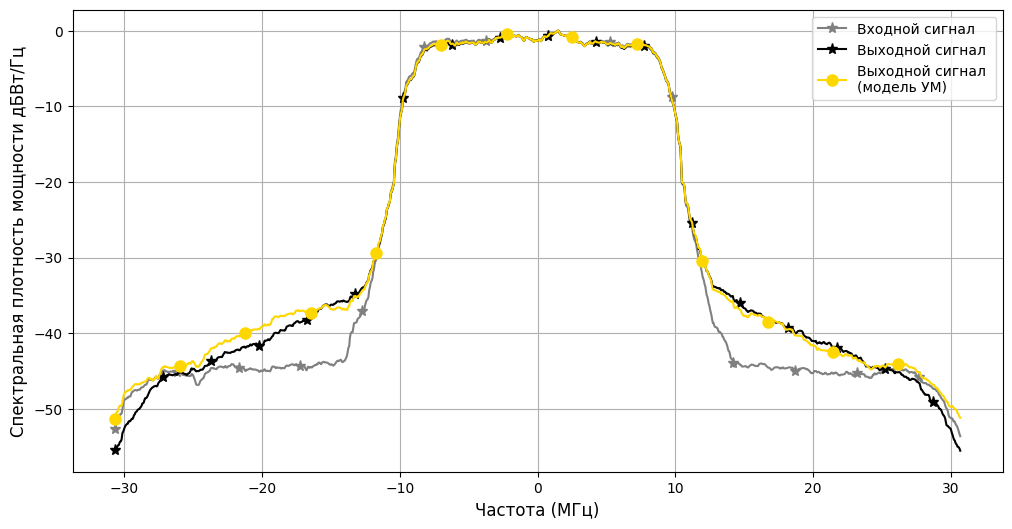

In [146]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_pred, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


In [10]:

def collect_als_statistics(main_model, M1, M2, P, R_range, num_runs, L, gamma, N, dataset_names_range, use_even_powers: bool = False):
    result_list = []
    
    for dataset_name in dataset_names_range:
        print(f"Dataset: {dataset_name}")
        
        dataset_path = f"datasets/{dataset_name}"
        container = data_loader.DataContainer()
        container.load_data(file_path=dataset_path)
        container.get_gained_signals()
        print(f"gain: {container.gain}")
        y_vec, H, M = prepare_data_for_als(x=container.train_input,
                                    y=container.train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )

        for R in R_range:
            print(f"R: {R}")

            for n in range(num_runs):
                print(f"Run: {n}")
                seed = hash((dataset_name, R, n)) % (2**32)
                torch.manual_seed(seed)
                model = main_model(R=R, M1=M1, M2=M2, P=P, use_even_powers=use_even_powers)
                
                model = als_identification_of_gmpcp(model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)
                
                x = utils.iq_to_complex(container.val_input_orig)

                y_pred = model(x)

                delay = max(model.M1, model.M2) - 1

                y_true = utils.iq_to_complex(container.val_output[delay:])

                gmpcp_nmse = metrics.compute_nmse(y_pred, y_true)
                print(F"NMSE: {gmpcp_nmse:.2f} dB")

                gmpcp_acepr = metrics.compute_acepr(
                    measured=y_pred,
                    predicted=y_true,
                    fs=container.input_signal_fs,
                    main_bandwidth=container.bw_main_ch,
                    adjacent_bandwidth=container.bw_main_ch,
                    channel_offset=container.bw_main_ch,
                    nperseg=container.nperseg
                )

                print(f"ACEPR: {gmpcp_acepr:.2f} dB")
                
                result_list.append({
                    'dataset': dataset_name,
                    'R': R,
                    'run': n,
                    'nmse': float(gmpcp_nmse),
                    'acepr': float(gmpcp_acepr),
                })
    
    return result_list

In [12]:
main_model = GMPCP
M1=11
M2=10
# P=8
P=8
N=4096
gamma = 1e-3
L = 20

R_range = [1, 2, 3, 4, 5, 6]
num_runs = 50
dataset_names_range = ('DPA_200MHz', 
                       'Custom_dataset', 
                       'Huawei_dataset',
                       'signal_samples_newPA_vo_filter_no_atten_-11_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-12_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-13_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-14_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-15_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-15_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-16_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-17_dBm',
                       )


result_list_odd = collect_als_statistics(main_model=main_model,
                       M1=M1,
                       M2=M2, 
                       P=P,
                       R_range=R_range,
                       num_runs=num_runs,
                       L=L,
                       gamma=gamma,
                       N=N,
                       dataset_names_range=dataset_names_range,
                       use_even_powers=False)

Dataset: DPA_200MHz
gain: 2.5208089351654053
R: 1
Run: 0
NMSE: -26.81 dB
ACEPR: -31.52 dB
Run: 1
NMSE: -30.76 dB
ACEPR: -37.94 dB
Run: 2
NMSE: -28.14 dB
ACEPR: -35.49 dB
Run: 3
NMSE: -31.29 dB
ACEPR: -38.26 dB
Run: 4
NMSE: -30.03 dB
ACEPR: -37.19 dB
Run: 5
NMSE: -31.45 dB
ACEPR: -38.31 dB
Run: 6
NMSE: -30.98 dB
ACEPR: -38.11 dB
Run: 7
NMSE: -31.36 dB
ACEPR: -38.24 dB
Run: 8
NMSE: -31.41 dB
ACEPR: -38.27 dB
Run: 9
NMSE: -31.16 dB
ACEPR: -38.20 dB
Run: 10
NMSE: -27.07 dB
ACEPR: -34.73 dB
Run: 11
NMSE: -30.67 dB
ACEPR: -38.05 dB
Run: 12
NMSE: -30.47 dB
ACEPR: -37.91 dB
Run: 13
NMSE: -31.23 dB
ACEPR: -38.16 dB
Run: 14
NMSE: -31.01 dB
ACEPR: -37.79 dB
Run: 15
NMSE: -30.24 dB
ACEPR: -37.12 dB
Run: 16
NMSE: -30.77 dB
ACEPR: -38.04 dB
Run: 17
NMSE: -30.93 dB
ACEPR: -38.12 dB
Run: 18
NMSE: -31.13 dB
ACEPR: -37.93 dB
Run: 19
NMSE: -30.58 dB
ACEPR: -38.00 dB
Run: 20
NMSE: -29.92 dB
ACEPR: -37.79 dB
Run: 21
NMSE: -31.38 dB
ACEPR: -38.31 dB
Run: 22
NMSE: -31.14 dB
ACEPR: -38.08 dB
Run: 23
NMSE: -31

In [13]:
from scipy import stats


def confidence_interval(values, confidence=0.95):
    values = np.asarray(values)

    if len(values) < 2:
        return 0.0

    sem = stats.sem(values)

    h = sem * stats.t.ppf(
        (1 + confidence) / 2,
        len(values) - 1
    )

    return h

def aggregate_measured_data(arrray):
    df = pd.DataFrame(arrray)
    grouped = df.groupby(['dataset', 'R'])
    df_agg = grouped.agg(
        nmse_mean=('nmse', 'mean'),
        nmse_std=('nmse', 'std'),
        nmse_count=('nmse', 'count'),
        nmse_ci=('nmse', confidence_interval),

        acepr_mean=('acepr', 'mean'),
        acepr_std=('acepr', 'std'),
        acepr_count=('acepr', 'count'),
        acepr_ci=('acepr', confidence_interval),
    ).reset_index()
    
    return df_agg

In [14]:
# df_result_odd = pd.DataFrame(result_list_odd)

# grouped = df_result_odd.groupby(['dataset', 'R'])

# df_result_odd_agg = grouped.agg(
#     nmse_mean=('nmse', 'mean'),
#     nmse_std=('nmse', 'std'),
#     nmse_count=('nmse', 'count'),
#     nmse_ci=('nmse', confidence_interval),

#     acepr_mean=('acepr', 'mean'),
#     acepr_std=('acepr', 'std'),
#     acepr_count=('acepr', 'count'),
#     acepr_ci=('acepr', confidence_interval),
# ).reset_index()


df_result_odd_agg = aggregate_measured_data(result_list_odd)
df_result_odd_agg.head()

,dataset,R,nmse_mean,nmse_std,nmse_count,nmse_ci,acepr_mean,acepr_std,acepr_count,acepr_ci
0,Custom_dataset,1,-26.946045,1.362260,50,0.387150,-33.997591,1.680786,50,0.477674
1,Custom_dataset,2,-41.063441,2.780022,50,0.790074,-48.753581,2.297463,50,0.652932
2,Custom_dataset,3,-45.669209,0.860599,50,0.244579,-50.350169,0.834506,50,0.237164
3,Custom_dataset,4,-45.415670,0.667402,50,0.189674,-49.196592,0.692465,50,0.196796
4,Custom_dataset,5,-45.496670,0.666363,50,0.189378,-49.234553,0.659480,50,0.187422


In [15]:
print(df_result_odd_agg)

                                            dataset  R  nmse_mean  nmse_std  \
0                                    Custom_dataset  1 -26.946045  1.362260   
1                                    Custom_dataset  2 -41.063441  2.780022   
2                                    Custom_dataset  3 -45.669209  0.860599   
3                                    Custom_dataset  4 -45.415670  0.667402   
4                                    Custom_dataset  5 -45.496670  0.666363   
5                                    Custom_dataset  6 -45.553334  0.731277   
6                                        DPA_200MHz  1 -30.569985  1.048339   
7                                        DPA_200MHz  2 -30.802595  1.032408   
8                                        DPA_200MHz  3 -30.943077  0.644385   
9                                        DPA_200MHz  4 -31.038648  0.697725   
10                                       DPA_200MHz  5 -31.143294  0.506255   
11                                       DPA_200MHz 

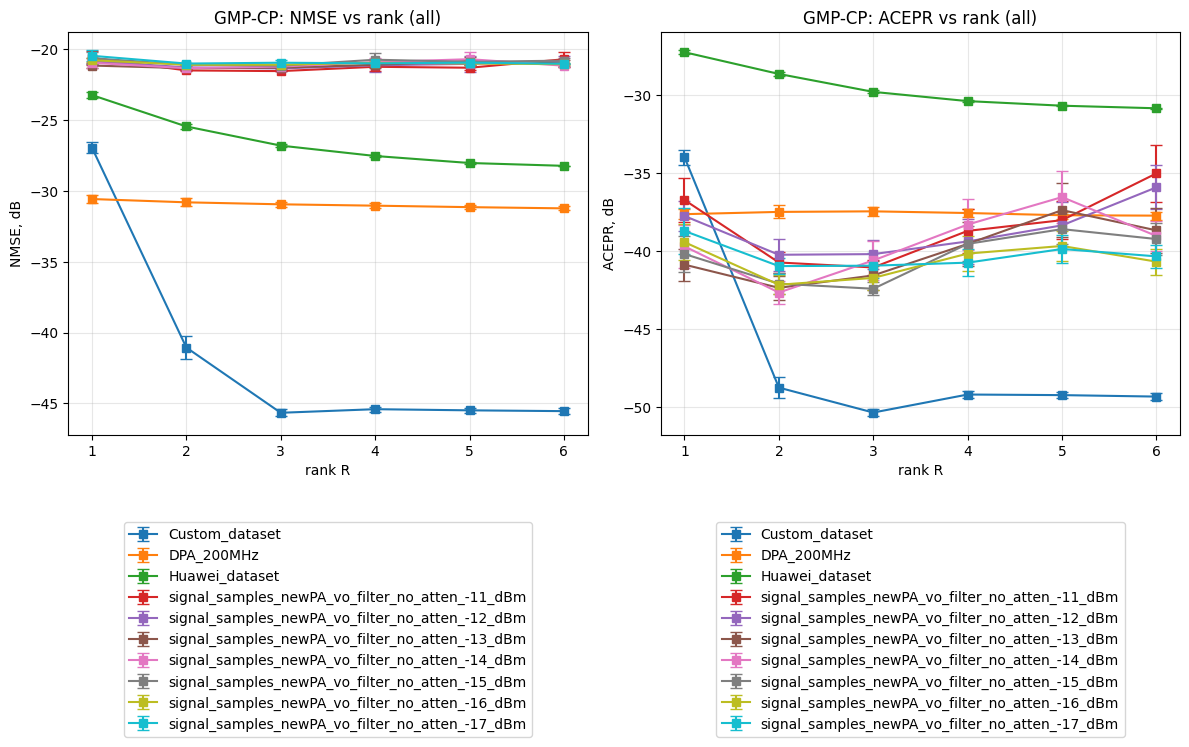

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for dataset_name, group in df_result_odd_agg.groupby('dataset'):

    group = group.sort_values('R')

    axes[0].errorbar(
        group['R'],
        group['nmse_mean'],
        yerr=group['nmse_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )

    axes[1].errorbar(
        group['R'],
        group['acepr_mean'],
        yerr=group['acepr_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )


axes[0].set_xlabel("rank R")
axes[0].set_ylabel("NMSE, dB")
axes[0].set_title("GMP-CP: NMSE vs rank (all)")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(np.arange(1, 7, 1))
axes[0].legend(loc="upper center",bbox_to_anchor=(0.5, -0.2))
# axes[0].legend()


axes[1].set_xlabel("rank R")
axes[1].set_ylabel("ACEPR, dB")
axes[1].set_title("GMP-CP: ACEPR vs rank (all)")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(np.arange(1, 7, 1))
axes[1].legend(loc="upper center",bbox_to_anchor=(0.5, -0.2))
# axes[1].legend()


plt.tight_layout()
plt.show()

Basic GMP

In [11]:
def prepare_data_for_gmp(x, y, M1, M2, P, N):
    x = utils.iq_to_complex(x)
    y = utils.iq_to_complex(y)
    
    max_delay = max(M1, M2)-1
    start = max_delay
    
    y_vec = y[start:start+N]

    # индексы задержек
    n_idx = torch.arange(N)[:,None]
    i_idx = torch.arange(M1)[None,:]
    j_idx = torch.arange(M2)[None,:]

    # x(t-i)
    x_i = x[start+n_idx-i_idx]

    # x(t-j)
    x_j = x[start+n_idx-j_idx]

    abs_xj = torch.abs(x_j)

    Phi = []

    for i in range(M1):
        for j in range(M2):
            for p in range(P):
                feature = (x_i[:,i] * abs_xj[:,j]**p)
                Phi.append(feature)

    Phi = torch.stack(Phi, dim=1)

    return y_vec, Phi

def identify_gmp(
    model,
    x,
    y,
    M1,
    M2,
    P,
    gamma=0
):

    # LS
    s = ridge_ls(x, y, gamma)

    # vec^-1(S)
    S = s.reshape(M1, M2, P)

    model.set_parameters(S)

    return model

In [ ]:
M1=11
M2=10
P=8
N=2048

gamma = 1e-3

y, x = prepare_data_for_gmp(x=container.train_input,
                                  y=container.train_output, 
                                  M1=M1, 
                                  M2=M2, 
                                  P=P, 
                                  N=N)


model_gmp = GMPTensor(M1=M1, M2=M2, P=P)

model_gmp = identify_gmp(
    model_gmp,
    x,
    y,
    M1,
    M2,
    P,
    gamma
)



NMSE: -36.02 dB
ACEPR: -39.32 dB


c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


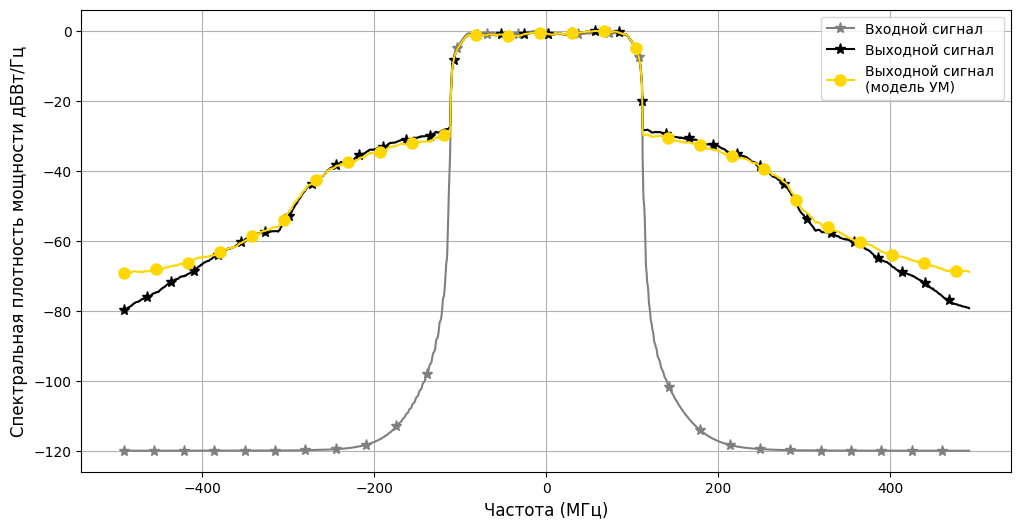

In [13]:
x_val = utils.iq_to_complex(container.val_input_orig)

with torch.no_grad():
    y_pred = model_gmp(x_val)

delay = max(model_gmp.M1, model_gmp.M2) - 1

y_true = utils.iq_to_complex(container.val_output[delay:])

gmp_nmse = metrics.compute_nmse(y_pred, y_true)
print(F"NMSE: {gmp_nmse:.2f} dB")

gmp_acepr = metrics.compute_acepr(
    measured=y_pred,
    predicted=y_true,
    fs=container.input_signal_fs,
    main_bandwidth=container.bw_main_ch,
    adjacent_bandwidth=container.bw_main_ch,
    channel_offset=container.bw_main_ch,
    nperseg=container.nperseg
)

print(f"ACEPR: {gmp_acepr:.2f} dB")


window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_pred, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


ILC

In [148]:
R=3
M1=11
M2=10
P=8
N=2048

gamma = 1e-3
L = 30
# torch.manual_seed(42)

pa_model = GMPCP(R=R, M1=M1, M2=M2, P=P, model_name='pa')

delay = pa_model.max_delay

y_vec, H, M = prepare_data_for_als(x=container.train_input,
                                    y=container.train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )


pa_model = als_identification_of_gmpcp(model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)

In [150]:
container.to_complex()
# container.to_iq()


with torch.autograd.profiler.profile(use_cuda=False) as prof:
    with torch.no_grad():
        output = pa_model.forward(container.val_input)

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                    Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
            aten::einsum         3.57%      49.400us        35.78%     495.500us     247.750us             2  
               aten::bmm        22.52%     311.800us        24.92%     345.100us     172.550us             2  
             aten::stack         0.81%      11.200us        13.19%     182.600us     182.600us             1  
               aten::cat        11.24%     155.700us        11.68%     161.800us     161.800us             1  
             aten::index        10.53%     145.800us        11.08%     153.400us      76.700us             2  
               aten::sum         7.55%     104.500us         7.93%     109.800us     109.800us             1  
 

In [154]:
u_k_train = learning.ilc_signal(container.train_input, container.train_output_target[delay:], pa_model, epochs=400, learning_rate=0.01)
u_k_val = learning.ilc_signal(container.val_input, container.val_output_target[delay:], pa_model, epochs=400, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target[delay:])
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

container.ilc_train_output = u_k_train
container.ilc_val_output = u_k_val



Epoch [0/400], Loss: 998.83447265625
Epoch [100/400], Loss: 9.432382583618164
Epoch [200/400], Loss: 0.09537196904420853
Epoch [300/400], Loss: 0.0013533494202420115
Epoch [399/400], Loss: 1.2712273019133136e-05
Выполнение заняло: 0:00:04
Epoch [0/400], Loss: 989.6949462890625
Epoch [100/400], Loss: 10.878156661987305
Epoch [200/400], Loss: 0.13912594318389893
Epoch [300/400], Loss: 0.00243367743678391
Epoch [399/400], Loss: 2.4913999368436635e-05
Выполнение заняло: 0:00:02
NMSE на выходе усилителя (ILC): -72.67 db


In [155]:
ilc_train_loader, ilc_val_loader = data_loader.build_dataloaders(container=container, 
                                                                 frame_length=frame_length, 
                                                                 batch_size=batch_size, 
                                                                 batch_size_eval=batch_size_eval, 
                                                                 arch="ilc")

IndexError: tuple index out of range

In [ ]:
epochs = 300
lr = 0.01

ilc_degree = 5
ilc_config = params.make_gmp_params(
    Ka=ilc_degree,
    La=ilc_degree,
    Kb=ilc_degree,
    Lb=ilc_degree,
    Mb=ilc_degree,
    Kc=ilc_degree,
    Lc=ilc_degree,
    Mc=ilc_degree,
)

dpd_model_ilc = GMP(**ilc_config, model_name="ilc")
# is_load = dpd_model_ilc.load_weights()
# optimizer = torch.optim.AdamW(dpd_model_ilc.parameters(), lr=lr)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=dpd_model_ilc, 
                   criterion=criterion, 
                   optimizer=optimizer, 
                   train_loader=ilc_train_loader, 
                   val_loader=ilc_val_loader, 
                   n_epochs=epochs, 
                   metric_criterion=metric_criterion,
                   scheduler=scheduler)
    dpd_model_ilc.save_weights()

casc_ilc_eval = utils.CascadeModel(model_1=dpd_model_ilc, model_2=pa_model)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=container.val_input)
nmse_ilc = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {nmse_ilc:.2f}")
